# nvImageCodec with PyTorch DataLoader integration

This notebook demonstrates how to integrate **NVIDIA nvImageCodec** with `torch.utils.data.DataLoader`
for maximum GPU throughput. The key insight is **batch GPU decoding** — submitting an entire
DataLoader batch to the GPU decoder in a single call — which fully saturates the GPU decode
pipeline and eliminates per-image CPU/GPU synchronization overhead. 

Standard PyTorch image pipelines decode images **on the CPU** (via Pillow) and then transfer
them to the GPU. This creates a CPU bottleneck that often starves the GPU during training.


## PyTorch input pipeline — a quick primer

Before the benchmarks, here is the smallest mental model of `torch.utils.data.DataLoader`. It is just an orchestrator built from a few small, swappable pieces:

| Piece | What it does | Where it runs | How we use it here |
|-------|--------------|---------------|--------------------|
| **`Dataset`** | Holds the data; `__getitem__(i) → sample` returns **one** item (e.g. image + label). | Inside the worker | We swap *what* it returns: a decoded tensor (per-item decode) vs. raw JPEG bytes (for batch decode). |
| **`Sampler`** | Produces the **index sequence** that drives `__getitem__` (sequential, shuffled, weighted, distributed, …). | Main process | Default — we never customize it. |
| **Workers** | Parallel processes (or threads, see below), each handling a **whole batch end-to-end** (`num_workers=…`). | Started by `DataLoader` via `multiprocessing` | We use `multiprocessing_context='spawn'` whenever GPU code runs inside a worker — see *Worker start methods* below for why `fork` would break the CUDA context. |
| **`collate_fn`** | Combines a list of `batch_size` samples into one batched tensor. | Inside the worker, **once per batch** (right after that worker's `__getitem__` calls) | **The key trick of this notebook**: we replace the default `torch.stack` with a single GPU batch-decode call. |
| **`DataLoader`** | Glues everything together and yields `(batch, labels)` to the training loop. | Main process | Standard — we just plug our custom pieces in. |

### Data flow

The crucial (and often surprising) point: **each worker handles one entire batch on its own** — it runs `__getitem__` `batch_size` times *and* `collate_fn` once, all inside that worker process. The main process never sees individual samples; it just consumes pre-collated batches from the workers' output queue.

```
        ┌──────────────────────────────────────────────────────────┐
        │              torch.utils.data.DataLoader                 │
        │       (main process — yields one batch at a time)        │
        └─────────────────────────┬────────────────────────────────┘
                                  │ Sampler + BatchSampler emit
                                  │ ONE GROUP of indices PER BATCH
                                  ▼
                  ┌─────────── work queue ────────────┐
                  │  batch 0: [3, 17, 42, 8, …]       │
                  │  batch 1: [11, 2, 24, 19, …]      │
                  │  batch 2: …                       │
                  └─────────────────┬─────────────────┘
                                    │ each batch group is dispatched
                                    │ to ONE worker (round-robin)
                                    ▼
            ┌──────────────────  Worker i  ──────────────────┐
            │                                                │
            │   indices = [3, 17, 42, 8, …]                  │
            │   samples = [dataset[i] for i in indices]      │  ← __getitem__ × B
            │   batch   = collate_fn(samples)                │  ← ONCE per batch
            │                                                │
            │   (workers 0 … N-1 each do this on a           │
            │    *different* batch, in parallel)             │
            └──────────────────────┬─────────────────────────┘
                                   │ collated batch sent back
                                   │ over IPC queue
                                   ▼
                     main process pulls completed batches
                       `for batch, labels in loader:` …
```

**Few things to note:**

- A worker receives **a whole batch's worth of indices**, not one index at a time. It runs `__getitem__` `batch_size` times *and then* runs `collate_fn` **once** on the resulting list — both inside the same worker. The collated batch is what travels back to the main process over the IPC queue.
- The main process does **not** call `collate_fn` and does **not** gather samples from different workers. The workers do all the collation; the parent just consumes already-batched tensors in the order the sampler dictated.
- When `num_workers=0` there are no worker processes at all — `DataLoader` runs the whole pipeline (sampling, `__getitem__`, `collate_fn`) inline in the main thread. The logic is identical, just not parallelised.

### How this maps to the rest of the notebook

| Approach | `Dataset.__getitem__` returns | `collate_fn` does | Decoder runs on |
|----------|-------------------------------|--------------------|-----------------|
| **0** — PIL baseline | decoded CPU tensor (`PIL → resize → ToTensor`) | default `torch.stack` | CPU, one image / worker |
| **1** — nvImageCodec per item (1.1 `num_workers=0`, 1.2 spawn, 1.3 forkserver) | decoded GPU tensor | default `torch.stack` | GPU, one image / worker |
| **2** — nvImageCodec batch collate | CodeStream | `decoder.decode(list_of_streams)` then stack | GPU, **whole batch at once** |

### Worker start methods

PyTorch's `DataLoader` uses separate *processes* (not threads) for each worker. This design goes back to Python's Global Interpreter Lock (GIL): on the standard (GIL-enabled) CPython build, true parallelism for CPU-bound tasks isn't possible with threads (PEP 703 free-threading is opt-in from 3.13 via the `python3.Xt` build), so workers run in independent interpreters to sidestep the GIL — important for CPU-heavy Python pipelines (torchvision/PIL, NumPy, image transforms, …). Process isolation also means a worker can crash or leak without taking the main process down.

For I/O-bound or GPU-heavy pipelines those guarantees come at a real cost (extra VRAM for a per-worker CUDA context, slow startup, IPC pickling). If you want to explore a thread-based alternative — where all workers share one CUDA context and skip the IPC tax — see the [NVIDIA threads blog post](https://developer.nvidia.com/blog/improved-data-loading-with-threads/); the rest of this notebook sticks with stock process-based workers.

`DataLoader(num_workers > 0, multiprocessing_context=…)` delegates worker creation to Python's `multiprocessing`, which offers three standard contexts. Each interacts with CUDA differently:

| Context | How a worker starts | CUDA-safe? | Per-worker overhead | When to use |
|---------|--------------------|------------|---------------------|-------------|
| `fork` | `os.fork()` — child is a copy-on-write clone of the parent | **No** once the parent has called any CUDA function | Cheapest startup, no extra VRAM | Pure-CPU pipelines (e.g. PIL baseline in *Approach 0*) |
| `spawn` | `fork()` + `execve()` — a fresh Python interpreter; **nothing** is inherited | **Yes** | Slow startup, ~300–700 MB VRAM (one CUDA context per worker) | Any path where the worker touches the GPU — Approaches 1.2 / 2 below |
| `forkserver` | A tiny CUDA-free helper process is started **once** via `spawn`; subsequent workers cheap-`fork` from *that* helper | **Yes** | Cheaper startup than `spawn` once the helper warms up | Production training loops that frequently create or destroy workers — see *Approach 1.3* |

#### Why `fork` breaks once CUDA has been initialized

The setup cell below calls `torch.cuda.is_available()`, which initialises a CUDA context in the parent. After that, `fork()` is essentially poisoned for GPU work in the child:

1. The CUDA driver tags every `CUcontext` with its **creator PID**. The child inherits the *handle* but not the ownership — the driver rejects the child's first call with `cudaErrorInitializationError`.
2. cudart has a per-process *"already initialised"* flag that is also inherited as `True`, so the runtime refuses to re-initialise in the child. Even an explicit `cudaDeviceReset()` cannot bring it back to a clean state.
3. The PyTorch caching allocator's reserved-pointer map, plus every Python object holding a `cudaStream_t` / `cudaEvent_t` / `nvimgcodec.Decoder` handle, still point into the parent's now-invalid context.

Only `execve()` — i.e. `spawn` — reliably clears all three. `forkserver` works because the fork-server itself was started via spawn *before* anything touched CUDA, so its `fork()`s produce children that have never seen a poisoned context.

#### What this notebook actually uses

| Approach | Worker start method | Why |
|----------|--------------------|-----|
| **Approach 0** — PIL baseline | `fork` (default) | Workers do pure CPU work, never touch CUDA — fork is fast and free |
| **Approach 1.1** — single-item, `num_workers=0` | none (single process) | No workers, no fork — the only safe way to do per-item GPU decode without a helper module |
| **Approach 1.2** — single-item, spawn workers | `spawn` | Each worker needs its own `Decoder` in its own CUDA context |
| **Approach 1.3** — single-item, forkserver workers | `forkserver` | Same correctness as 1.2 with cheaper per-worker startup once the helper is warm |
| **Approach 2** — batch `collate_fn` | `spawn` | Each worker needs its own `Decoder` in its own CUDA context; `collate_fn` does the batched GPU work |

In short: **`fork` is fine for Approach 0 (pure CPU) and for `num_workers=0` (where no worker is forked at all); Approaches 1.2 and 2 use `spawn` for the GPU workers.** Approach 1.3 demonstrates `forkserver` as a cheaper-startup variant.

## Setup

In [1]:
import gc
import os
import platform
import sys
import time
import shutil
import urllib.request
import zipfile
import pathlib
import threading
import warnings
from typing import List, Optional

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from nvidia import nvimgcodec

def _cpu_model_name() -> str:
    """Best-effort CPU model name (Linux /proc/cpuinfo, fall back to ``platform``)."""
    if sys.platform.startswith("linux"):
        try:
            with open("/proc/cpuinfo") as f:
                for line in f:
                    if line.startswith("model name"):
                        return line.split(":", 1)[1].strip()
        except OSError:
            pass
    return platform.processor() or platform.machine() or "unknown"

print(f"Python      : {sys.version.split()[0]}")
print(f"CPU         : {_cpu_model_name()}")
print(f"CPU cores   : {os.cpu_count()} (logical)")
print(f"PyTorch     : {torch.__version__}")
print(f"nvImageCodec: {nvimgcodec.__version__}")
print(f"Start methods (multiprocessing): {torch.multiprocessing.get_all_start_methods()}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU        : {torch.cuda.get_device_name(0)}")
    print(f"GPU count  : {torch.cuda.device_count()}")

Python      : 3.12.3
CPU         : AMD EPYC 7413 24-Core Processor
CPU cores   : 48 (logical)
PyTorch     : 2.12.0+cu130
nvImageCodec: 0.9.0
Start methods (multiprocessing): ['fork', 'spawn', 'forkserver']
CUDA available: True
GPU        : NVIDIA H100 80GB HBM3
GPU count  : 1


## Prepare Benchmark Dataset

We need a set of JPEG images large enough to show stable throughput numbers.
The cell below checks for an existing local image folder, then downloads a small
public JPEG dataset if needed, and finally replicates it to reach `N_IMAGES` total.

**Pre-resize on disk.** All approaches in this notebook stack a batch into a single
tensor, so they all require identical sample shapes. Rather than charging each
approach for a per-image `T.Resize` / `F.interpolate` call in its hot path (which
would put the same preprocessing in different places and make the comparison harder
to read), we resize every sample to `BENCHMARK_H`×`BENCHMARK_W` *once*, here, into a
`_prepared/` cache directory. Originals (yours or the downloaded seed set) are left
untouched, and the cache is reused on subsequent notebook runs. The result: the
timed regions later measure **decode** throughput, not preprocessing.

> **Tip:** Set `BENCHMARK_IMAGE_DIR` to your own folder of JPEGs to use real data —
> the pre-resize step still runs once to populate `_prepared/`.

In [2]:
# ── Configuration ──────────────────────────────────────────────────────────────
BENCHMARK_IMAGE_DIR = os.getenv("BENCHMARK_IMAGE_DIR", "./benchmark_images")
N_IMAGES   = 2000   # total images in benchmark set
BATCH_SIZE = 32
NUM_WORKERS = 8     # I/O worker processes
N_WARMUP_BATCHES = 3
# Must be large relative to NUM_WORKERS * prefetch_factor (= 16 with PyTorch defaults).
# At t_start the iterator may already hold that many pre-decoded batches produced
# during warmup, so a small n_measure inflates the reported throughput. See the note
# above benchmark() for the full argument.
N_BENCHMARK_BATCHES = 200
# All loaders use this H×W; the dataset prep step below resizes every image to
# this size on disk, so the timed regions later don't pay per-image resize cost.
# Spawn helper modules (%%writefile below) read NVIMGCODEC_NUM_WORKERS from the
# environment to cap the Decoder's CPU thread pool.
BENCHMARK_H, BENCHMARK_W = 256, 256
os.environ["NVIMGCODEC_NUM_WORKERS"] = str(NUM_WORKERS)
# ───────────────────────────────────────────────────────────────────────────────

benchmark_dir = pathlib.Path(BENCHMARK_IMAGE_DIR)

def _collect_jpegs(folder: pathlib.Path) -> List[pathlib.Path]:
    return sorted(p for ext in ("*.jpg", "*.jpeg", "*.JPEG", "*.JPG")
                  for p in folder.rglob(ext))

existing = _collect_jpegs(benchmark_dir) if benchmark_dir.exists() else []

if len(existing) >= N_IMAGES:
    image_paths = [str(p) for p in existing[:N_IMAGES]]
    print(f"Using {len(image_paths)} existing images from {benchmark_dir}")
else:
    # ── Download a small JPEG dataset (public PyTorch tutorial archive) ─────────
    # Alternatively: point BENCHMARK_IMAGE_DIR at any folder with ≥N_IMAGES JPEGs
    SEED_DIR = benchmark_dir / "_seed"
    SEED_DIR.mkdir(parents=True, exist_ok=True)

    seed_files = _collect_jpegs(SEED_DIR)
    if not seed_files:
        print("Downloading sample JPEG images (PyTorch tutorial faces archive) …")
        # Public JPEGs on download.pytorch.org. Hugging Face ILSVRC mirrors often return 401 (gated).
        _url = "https://download.pytorch.org/tutorial/faces.zip"
        _zip = SEED_DIR / "faces.zip"
        try:
            urllib.request.urlretrieve(_url, _zip)
            with zipfile.ZipFile(_zip) as zf:
                zf.extractall(SEED_DIR)
            _zip.unlink()
        except Exception as e:
            print(f"  Download failed ({e}).")
        seed_files = _collect_jpegs(SEED_DIR)
        print(f"  Seed images: {len(seed_files)}")

    if not seed_files:
        raise RuntimeError(
            f"No seed JPEGs found under {SEED_DIR}. "
            "The download from https://download.pytorch.org/tutorial/faces.zip failed "
            "or the archive contained no JPEGs. Set BENCHMARK_IMAGE_DIR to a folder "
            f"with at least one JPEG, or place images under {SEED_DIR}."
        )

    # ── Replicate seed images to reach N_IMAGES ────────────────────────────────
    OUT_DIR = benchmark_dir / "images"
    OUT_DIR.mkdir(parents=True, exist_ok=True)
    existing = _collect_jpegs(OUT_DIR)
    if len(existing) < N_IMAGES:
        print(f"Replicating seed images to {N_IMAGES} total …")
        for i in range(N_IMAGES):
            src = seed_files[i % len(seed_files)]
            dst = OUT_DIR / f"img_{i:05d}.jpg"
            if not dst.exists():
                shutil.copy2(src, dst)
        existing = _collect_jpegs(OUT_DIR)
    image_paths = [str(p) for p in existing[:N_IMAGES]]
    print(f"Benchmark dataset ready: {len(image_paths)} images in {OUT_DIR}")

# ── Pre-resize once, on disk, to BENCHMARK_H × BENCHMARK_W ─────────────────────
# Every approach below stacks a batch into a single tensor (default_collate ≡
# torch.stack), which requires identical shapes. Doing the resize once here —
# instead of inside each __getitem__ / collate_fn — keeps the timed regions
# focused on decode and avoids charging the same preprocessing work to different
# approaches in different places. Originals are left untouched in the source
# directory; the resized cache lives next to them in `_prepared/`.
PREPARED_DIR = benchmark_dir / "_prepared"
PREPARED_DIR.mkdir(parents=True, exist_ok=True)
prepared = _collect_jpegs(PREPARED_DIR)
if len(prepared) < N_IMAGES:
    print(f"Pre-resizing images to {BENCHMARK_H}x{BENCHMARK_W} → {PREPARED_DIR} …")
    for i, src in enumerate(image_paths):
        dst = PREPARED_DIR / f"img_{i:05d}.jpg"
        if dst.exists():
            continue
        with Image.open(src) as im:
            im.convert("RGB").resize(
                (BENCHMARK_W, BENCHMARK_H), Image.BILINEAR
            ).save(dst, "JPEG", quality=90)
    prepared = _collect_jpegs(PREPARED_DIR)
image_paths = [str(p) for p in prepared[:N_IMAGES]]
print(f"Using {len(image_paths)} pre-resized images from {PREPARED_DIR}")

Using 2000 existing images from benchmark_images
Pre-resizing images to 256x256 → benchmark_images/_prepared …


Using 2000 pre-resized images from benchmark_images/_prepared


## Benchmark Helper

A unified timing function. It:
1. Runs `N_WARMUP_BATCHES` batches (GPU warm-up, JIT compilation, worker spawning)
2. Times `N_BENCHMARK_BATCHES` batches
3. Reports **images / second** and **ms / batch**

For GPU-decoded pipelines the batch is already on device; for CPU pipelines `.cuda()` is
called inside the loop so the transfer latency is fairly counted.

> Images were resized to `BENCHMARK_H`×`BENCHMARK_W` once on disk in the prep cell, so
> none of the approaches below run `T.Resize` / `F.interpolate` inside `__getitem__` or
> `collate_fn`. The throughput numbers are decode + a cheap permute / normalize / stack.

### A note on prefetch and measurement window

`iter(loader)` immediately starts the worker pool and lets it prefetch up to
`NUM_WORKERS * prefetch_factor` batches *before* the timer ever starts. By the time
the warmup loop ends, the iterator's internal queue can hold that many already-decoded
batches that were produced during warmup (not counted in the timed window).

If the consumer (the timed loop) is faster than the producer (workers), it drains
those pre-decoded batches "for free" during the timed window, and the reported
throughput is inflated by roughly `(Q_start - Q_end) / n_measure`, where `Q_*` is
the queue depth at the start/end of measurement. With the PyTorch defaults
(`NUM_WORKERS=8`, `prefetch_factor=2`) the queue caps at 16, so we keep
`N_BENCHMARK_BATCHES` well above that (`= 200`) to push the worst-case bias under
~8%. Disabling prefetch (`prefetch_factor=1` is the minimum PyTorch allows with
workers) would also remove the bias, but it would erase the pipelining benefit that
multi-worker DataLoader exists to provide — so the comparison would no longer
reflect realistic training-loop throughput.

In [3]:
def benchmark(loader: DataLoader,
              n_warmup: int = N_WARMUP_BATCHES,
              n_measure: int = N_BENCHMARK_BATCHES,
              to_gpu: bool = True) -> dict:
    """
    Measure DataLoader throughput.

    Returns dict with keys: images_per_sec, ms_per_batch, total_images.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    iterator = iter(loader)

    # warm-up
    for _ in range(n_warmup):
        try:
            imgs, _ = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            imgs, _ = next(iterator)
        if to_gpu and imgs.device.type == "cpu":
            imgs = imgs.to(device, non_blocking=True)
        if device.type == "cuda":
            torch.cuda.synchronize()

    # measure
    total_images = 0
    t_start = time.perf_counter()
    for _ in range(n_measure):
        try:
            imgs, _ = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            imgs, _ = next(iterator)
        if to_gpu and imgs.device.type == "cpu":
            imgs = imgs.to(device, non_blocking=True)
        if device.type == "cuda":
            torch.cuda.synchronize()
        total_images += imgs.shape[0]

    elapsed = time.perf_counter() - t_start
    ips = total_images / elapsed
    mspb = elapsed / n_measure * 1000
    return {"images_per_sec": ips, "ms_per_batch": mspb, "total_images": total_images}


def release_loader(loader: DataLoader) -> None:
    """Drain prefetched CUDA tensors before the producing workers exit.

    Batches that the iterator pre-fetched but our benchmark loop didn't
    consume (the in-flight + queued items) become orphaned CUDA IPC tensors
    in main once the workers die — PyTorch then logs ``Producer process has
    been terminated before all shared CUDA tensors released`` once per
    orphan. Stopping new prefetch and iterating to ``StopIteration`` drops
    every reference while the producers are still alive. Dropping the
    iterator afterwards triggers the normal ``__del__`` -> worker join.
    """
    it = getattr(loader, "_iterator", None)
    if it is None:
        return
    it._try_put_index = lambda: None  # stop the iterator from queuing more work
    try:
        while True:
            next(it)                   # drain in-flight batches, dropping each ref
    except StopIteration:
        pass
    loader._iterator = None


results = {}  # populated by each section below

## Approach 0: Baseline — PIL + torchvision

The de-facto standard pipeline: Pillow decodes images on CPU worker processes,
`Resize` + `ToTensor()` convert to a fixed spatial size and float, then the training
loop moves batches to the GPU.

```
worker  →  open file  →  PIL.Image.open  →  Resize  →  ToTensor (HWC→CHW, /255)  →  collate  →  GPU .to()
```

> **Bottleneck**: CPU JPEG decompression is sequential per image. With many workers
> it scales, but each decode still competes for CPU cache and memory bandwidth.

In [4]:
class PilDataset(Dataset):
    """Standard torchvision-style dataset using PIL for decoding."""

    def __init__(self, paths: List[str]):
        self.paths = paths
        # Images are pre-resized on disk (see "Prepare Benchmark Dataset"),
        # so the per-sample transform is just uint8 → CHW float32 in [0, 1].
        self.transform = T.ToTensor()

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), 0  # (tensor CHW float32, dummy label)


pil_loader = DataLoader(
    PilDataset(image_paths),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    pin_memory=True,          # fast CPU→GPU transfer
    persistent_workers=True,  # keep workers alive across epochs
    prefetch_factor=2,
)

r = benchmark(pil_loader, to_gpu=True)
results["PIL + torchvision"] = r
print(f"PIL + torchvision: {r['images_per_sec']:.0f} img/s  |  {r['ms_per_batch']:.1f} ms/batch")

# Release this approach's workers and any pinned-memory / CUDA caches before the next one runs.
release_loader(pil_loader)
del pil_loader
gc.collect()
torch.cuda.empty_cache()

PIL + torchvision: 2395 img/s  |  13.3 ms/batch


## Approach 1: nvImageCodec — Single-Image Decode in `__getitem__`

The simplest way to plug nvImageCodec into a DataLoader: each `__getitem__` call decodes **one** image on the GPU. This is the most direct mental migration from a PIL-based pipeline ("just swap the decoder"), and it lets us isolate the cost of the per-image dispatch before we look at batching.

```
worker  →  open file  →  decoder.decode(stream)  →  torch.as_tensor  →  collate
```

We benchmark three variants of this approach:

- **Approach 1.1 — `num_workers=0`** (single-process). All decode work happens in the kernel's main thread. Safe, simple, no fork/CUDA gymnastics — but no parallelism: I/O, header parsing and GPU dispatch are all serial.
- **Approach 1.2 — Spawn multiple workers.** N independent processes (started via `multiprocessing_context='spawn'`), each with its own CUDA context and its own `Decoder`. Workers prefetch in parallel, so the *main* thread isn't blocked, but every worker is still dispatching one image at a time to the same hardware decoder.
- **Approach 1.3 — Forkserver workers.** Same correctness model as 1.2 (per-worker CUDA context, per-worker `Decoder`), but workers `fork()` from a tiny pre-warmed helper process instead of `execve`-ing a fresh Python — startup is much cheaper once the helper is warm.

### Limitations that apply to 1.1, 1.2 and 1.3

- **No batch parallelism in the decoder.** nvImageCodec dispatches one image at a time, so the hardware decoder (NVDEC + cuJPEG) is mostly idle between calls. Approach 2 fixes this by sending the whole batch in a single call.
- **High per-image dispatch overhead.** Each image pays a full CUDA launch + per-image allocation. For small JPEGs this overhead dwarfs the actual decode work.

### Additional costs that the multi-worker variants (1.2 / 1.3) introduce over 1.1

- **Per-worker CUDA context**: ~300–700 MB VRAM each. With `N=4` workers you can lose 1–3 GB before you've decoded a single image.
- **Worker startup**: slow per worker for `spawn` (1.2), much cheaper per worker for `forkserver` (1.3) after the helper has warmed up. `persistent_workers=True` amortises either cost across epochs but you still pay it once at the start.
- **No shared hardware-decode pipeline**: all N workers are queueing single images to the same physical decoder. 4 workers do **not** give a 4× speedup — typically 1.5–2.5× over 1.1, and sometimes *less* because of allocator and dispatch contention.

> If those caveats look like an argument for batch decode, that is exactly what Approach 2 demonstrates. From Approach 2 onwards the notebook sticks with `spawn` for simplicity — `forkserver` (1.3) is a drop-in replacement for any of the later approaches if start-up time matters.

### Approach 1.1: `num_workers=0`

No worker processes — the kernel's main thread runs `Dataset.__getitem__`, the `Decoder` lives in the same process as the rest of the notebook, and there is no IPC, no pickling, and no fork-vs-CUDA worry. This is the most honest "what does single-image GPU decode cost?" measurement we can take.

The Dataset just opens a file, hands the bytes to a thread-local `Decoder`, and converts the result into a CHW float tensor.

In [5]:
# Thread-local decoder: with thread DataLoader workers each thread gets its own Decoder;
# with num_workers=0 only the main thread runs __getitem__.
_decoder_tls = threading.local()


def _decoder_for_this_thread() -> nvimgcodec.Decoder:
    dec = getattr(_decoder_tls, "decoder", None)
    if dec is None:
        _decoder_tls.decoder = nvimgcodec.Decoder(max_num_cpu_threads=1) # do not need to more threads for single image decode
    return _decoder_tls.decoder


class NvSingleDataset(Dataset):
    """
    nvImageCodec single-image decode inside __getitem__.
    """

    def __init__(self, paths: List[str]):
        self.paths = paths

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        dec = _decoder_for_this_thread()
        code_stream = nvimgcodec.CodeStream(self.paths[idx])
        img = dec.decode(code_stream)                          # GPU decode, single image
        if img is None:
            raise RuntimeError(
                f"nvImageCodec returned None for {self.paths[idx]!r}. "
                "Check that the file exists and contains a decodable image."
            )
        # Images are pre-resized on disk, so no F.interpolate here — just normalize and HWC→CHW.
        tensor = torch.as_tensor(img.cuda(), device="cuda").float() / 255.0   # HWC float32 on GPU
        tensor = tensor.permute(2, 0, 1)                                       # CHW
        return tensor, 0

nv_single_loader_0 = DataLoader(
    NvSingleDataset(image_paths),
    batch_size=BATCH_SIZE,
    num_workers=0,
)

r = benchmark(nv_single_loader_0, to_gpu=False)  # already on GPU
results[f"nvImageCodec single (num_workers=0)"] = r
print(f"nvImageCodec single (num_workers=0): {r['images_per_sec']:.0f} img/s  |  {r['ms_per_batch']:.1f} ms/batch")

# Drop references so the per-thread decoder + dataset can be collected before the next approach runs.
release_loader(nv_single_loader_0)
del nv_single_loader_0
gc.collect()
torch.cuda.empty_cache()

nvImageCodec single (num_workers=0): 797 img/s  |  39.9 ms/batch


### Approach 1.2: Spawn multiple workers

Approach 1.1 leaves CPU work (file I/O, header parse, Python overhead) serialised in the main thread. The natural next step is to give that work to N DataLoader workers and let them prefetch while training consumes the previous batch.

But once a worker process has to call `nvimgcodec.Decoder().decode(...)` we cannot use the default `fork` start method: a forked child inherits the parent's CUDA *file descriptors* but **not** its CUDA context (see *Worker start methods* in the primer for the full story). The first GPU call in the child either fails or silently returns garbage.

So we use **`multiprocessing_context='spawn'`**: each worker is a fresh `python` process that initialises its own CUDA context. The trade-off is real:

| What you get | What you pay |
|--------------|--------------|
| Per-worker parallel I/O and Python work | Per-worker CUDA context (~300–700 MB VRAM each) |
| Per-worker `Decoder` (no contention) | Slow worker startup (scales with N); amortised by `persistent_workers=True` |
| Clean isolation (one worker dying doesn't poison the rest) | Anything passed to the worker (Dataset, `worker_init_fn`, `collate_fn`) must be **picklable by reference** — i.e. importable from a real module, not from Jupyter's `__main__` |

That last row is the source of the `AttributeError: Can't get attribute 'NvSingleSpawnDataset' on <module '__main__'>` you'll see if you try to define the Dataset class inline in a notebook cell — which is why the next cell uses `%%writefile` to externalise the helpers.

#### Why we move worker-visible code into a separate `.py` file *here*

`DataLoader(num_workers > 0, multiprocessing_context='spawn')` starts each worker as a **fresh** Python interpreter and **pickles** the `Dataset`, `worker_init_fn`, and `collate_fn` over a pipe. Pickle records a class **by reference** — `('module_name', 'ClassName')` — not by value. The worker then calls `import module_name` and looks up `ClassName`.

That is where Jupyter trips up: a class defined in a notebook cell lives in the kernel's `__main__`, which is *interactive* and not an importable module. Pickle dutifully records `('__main__', 'NvSingleSpawnDataset')`, the spawn worker imports *its own* `__main__` (which is `multiprocessing.spawn`), and you get:

```
AttributeError: Can't get attribute 'NvSingleSpawnDataset' on <module '__main__' …>
```

The fix is to move everything the worker has to resolve — the `Dataset` class, the `worker_init_fn`, the `collate_fn`, and anything they reference — into a real `.py` module on disk. The pickle then records `('nv_spawn_helpers', 'NvSingleSpawnDataset')`, the worker runs `import nv_spawn_helpers`, and the lookup succeeds.

The next cell uses Jupyter's `%%writefile` magic to drop that module right next to this notebook, so re-running the notebook on a fresh machine regenerates the file. **Restart the kernel** before re-running the spawn loader if you edit `nv_spawn_helpers.py`, otherwise the old class definition lingers in the kernel and the workers (which re-import the *file*) drift out of sync with what the kernel believes.

> **In a regular `.py` script you don't need a separate file.** Define `NvSingleSpawnDataset`, `init_nv_worker`, `nvimgcodec_collate_fn`, etc. at the top of your script, then guard the *driver* code (the `DataLoader` construction and the training loop) with `if __name__ == '__main__':`. When the spawn worker re-imports your script it is loaded under its real filename (not `__main__`), the `if`-guard prevents the worker from launching its own workers again, and pickle finds the classes at module scope. The `%%writefile` dance is purely a Jupyter accommodation because cell-defined classes only exist inside the live kernel.

In [6]:
%%writefile nv_spawn_helpers.py
"""Approach 1 helpers — single-image GPU decode inside ``__getitem__``.

Each spawn worker imports this module afresh, so the module-level
``_worker_decoder`` ends up bound to that worker's own CUDA context.
"""
import atexit
from typing import List, Optional

import torch
from torch.utils.data import Dataset

from nvidia import nvimgcodec

# Per-worker singleton — one Decoder per worker process.
_worker_decoder: Optional[nvimgcodec.Decoder] = None


def _release_worker_decoder() -> None:
    """Drop the per-worker Decoder while CUDA is still alive in this process."""
    global _worker_decoder
    if _worker_decoder is not None:
        # Drain any in-flight decode work before releasing the Decoder so its
        # destructor doesn't synchronize against a half-torn-down stream.
        torch.cuda.synchronize()
        _worker_decoder = None
    # Flush the producer-side CUDA IPC limbo so already-acked tensors get
    # released NOW. Otherwise their CudaIPCSentData entries linger until
    # process exit and CudaIPCRefCountersFile::~ prints "Producer process
    # has been terminated before all shared CUDA tensors released".
    torch.cuda.ipc_collect()


def init_nv_worker(worker_id: int) -> None:
    """``worker_init_fn`` — construct the per-worker Decoder AFTER spawn so
    it is bound to the worker's own CUDA context, not the parent's."""
    global _worker_decoder
    # Force torch CUDA init NOW so torch's CUDA-shutdown atexit is registered
    # before ours; LIFO order then guarantees our handler runs first at exit.
    torch.cuda.init()
    # Single-image decode: one CPU helper thread is enough; the default
    # (= num cores per worker) would oversubscribe with NUM_WORKERS spawn procs.
    _worker_decoder = nvimgcodec.Decoder(max_num_cpu_threads=1)
    atexit.register(_release_worker_decoder)


class NvSingleSpawnDataset(Dataset):
    """Decode one image per ``__getitem__`` call on the GPU."""

    def __init__(self, paths: List[str]):
        self.paths = paths

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        global _worker_decoder
        if _worker_decoder is None:                # num_workers=0 fallback
            _worker_decoder = nvimgcodec.Decoder(max_num_cpu_threads=1)
        img = _worker_decoder.decode(nvimgcodec.CodeStream(self.paths[idx]))
        if img is None:
            raise RuntimeError(
                f"nvImageCodec returned None for {self.paths[idx]!r}. "
                "Check that the file exists and contains a decodable image."
            )
        # Images are pre-resized on disk; no F.interpolate here.
        t = torch.as_tensor(img.cuda(), device="cuda").float() / 255.0
        t = t.permute(2, 0, 1)                                # HWC → CHW
        return t, 0

Overwriting nv_spawn_helpers.py


In [7]:
from nv_spawn_helpers import NvSingleSpawnDataset, init_nv_worker

nv_single_loader_n = DataLoader(
    NvSingleSpawnDataset(image_paths),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    multiprocessing_context='spawn',
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=init_nv_worker,
)

r = benchmark(nv_single_loader_n, to_gpu=False)  # already on GPU
results[f"nvImageCodec single (num_workers={NUM_WORKERS})"] = r
print(f"nvImageCodec single (num_workers={NUM_WORKERS}): {r['images_per_sec']:.0f} img/s  |  {r['ms_per_batch']:.1f} ms/batch")

# Shut down the spawn workers so their per-worker CUDA contexts are freed before the next approach runs.
# Without this, the persistent workers from each approach stack up and can OOM smaller GPUs.
release_loader(nv_single_loader_n)
del nv_single_loader_n
gc.collect()
torch.cuda.empty_cache()

nvImageCodec single (num_workers=8): 4385 img/s  |  7.2 ms/batch


### Approach 1.3: `forkserver` workers

`spawn` workers (Approach 1.2) are correct but pay a noticeable startup tax per worker, which can dominate short or interactive runs. `forkserver` keeps the correctness guarantees (each worker still gets its own CUDA context) while bringing startup down significantly per worker.

How it works in three lines:

1. The first time a `forkserver`-context DataLoader is created, Python spawns a **single** tiny helper process — a fresh Python interpreter, no inherited CUDA state.
2. The helper sits idle, waiting for "please fork me a child" requests from the parent.
3. Every subsequent worker is `fork()`-ed *from the helper* (not from this notebook's CUDA-tainted parent), so each worker starts as a copy-on-write clone of the clean helper — the `fork()` itself is fast and CUDA-safe because the helper has never touched CUDA.


The cell below probes `torch.multiprocessing.get_all_start_methods()` and skips the benchmark gracefully if the platform doesn't support `forkserver` (e.g. Windows).


In [8]:
import multiprocessing as mp

available_methods = torch.multiprocessing.get_all_start_methods()
print(f"Available multiprocessing start methods: {available_methods}")
print(f"  - 'forkserver' supported: {'forkserver' in available_methods}")

if 'forkserver' not in available_methods:
    print("\nSkipping Approach 1.3 \u2014 'forkserver' is not available on this platform.")
else:
    nv_single_loader_fs = DataLoader(
        NvSingleSpawnDataset(image_paths),
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        multiprocessing_context='forkserver',
        persistent_workers=True,
        prefetch_factor=2,
        worker_init_fn=init_nv_worker,
    )

    r = benchmark(nv_single_loader_fs, to_gpu=False)
    results[f"nvImageCodec single + forkserver (num_workers={NUM_WORKERS})"] = r
    print(f"\nnvImageCodec single + forkserver (num_workers={NUM_WORKERS}): "
          f"{r['images_per_sec']:.0f} img/s  |  {r['ms_per_batch']:.1f} ms/batch")

    # Shut down forkserver workers and free their per-worker CUDA contexts before the next approach runs.
    release_loader(nv_single_loader_fs)
    del nv_single_loader_fs
    gc.collect()
    torch.cuda.empty_cache()

Available multiprocessing start methods: ['fork', 'spawn', 'forkserver']
  - 'forkserver' supported: True



nvImageCodec single + forkserver (num_workers=8): 4514 img/s  |  7.0 ms/batch


## Approach 2: nvImageCodec Batch Decode via `collate_fn`

**Split responsibilities:**

- **`__getitem__`** (runs inside the worker, `num_workers > 0`): pure CPU — build a
  `nvimgcodec.CodeStream` from the file path. That parses the JPEG header only; no
  pixel decode and no GPU work happen here, so the dataset has no CUDA dependency.
- **`collate_fn`** (also runs inside the worker, **once per batch**): receives the
  full list of `CodeStream` samples and calls
  `decoder.decode(list_of_code_streams)` — **one GPU call per batch**. The
  per-worker `Decoder` is constructed by a `worker_init_fn` (`init_nv_collate_worker`)
  that runs once after the spawn worker is up, so it binds to the worker's own
  CUDA context. The `if _collate_decoder is None: …` block inside the collate
  function is only a `num_workers=0` fallback.

```
workers (CPU only)              worker collate_fn (GPU batch decode)
─────────────────────           ────────────────────────────────────
open file → CodeStream ──┐
open file → CodeStream ──┤  collate_fn:
open file → CodeStream ──┼──► decoder.decode([CodeStream, CodeStream, ...])  →  batch tensor
open file → CodeStream ──┤    (ONE GPU call, full batch parallelism)
    ...                ──┘
```

This maximises GPU decode occupancy: the hardware sees `BATCH_SIZE` images at once
and can schedule them across all decode engines simultaneously.

> **Implementation note:** we use the same **spawn**-context recipe as Approach 1 — workers are
> fresh Python processes, each with its own CUDA context and its own `Decoder`. What changes is
> *what* the worker does: in Approach 1 the worker decoded one image per `__getitem__`; here
> `__getitem__` is pure CPU (build a `nvimgcodec.CodeStream` from a file path) and the GPU work
> happens once per batch inside `collate_fn`. Because we picked spawn, we put the worker-visible
> code (the dataset class, the `worker_init_fn`, and the `collate_fn`) into a second helper
> module — see the next two cells.

### A second helper module for Approach 2

Just like Approach 1 had its own `nv_spawn_helpers.py`, Approach 2 needs its own worker-visible module. Could we put everything in one file? Yes — but keeping them apart makes the *step-by-step* story clearer: each approach has exactly the code it needs, and you can read either file in isolation.

The new module — `nv_spawn_collate_helpers.py` — contains three things:

| Name | Purpose |
|------|---------|
| `CodeStreamDataset` | `__getitem__` returns a `nvimgcodec.CodeStream` built from the file path — pure CPU, no GPU work in the worker before collate. |
| `init_nv_collate_worker` | `worker_init_fn` that constructs a per-worker `Decoder` *after* spawn (so it is bound to the worker's own CUDA context). |
| `nvimgcodec_collate_fn` | The actual `collate_fn` — one `decoder.decode([streams])` call decodes the whole batch on the GPU, then permutes HWC→CHW and stacks. |

Same Jupyter caveat as before: cell-defined names live in `__main__` and can't be pickled to spawn workers, so we materialize this module on disk via `%%writefile`. In a regular `.py` script you would simply put the same four definitions at module scope.

In [9]:
%%writefile nv_spawn_collate_helpers.py
"""Approach 2 helpers — pure-CPU ``__getitem__``, batch GPU decode in
``collate_fn``.

Each spawn worker imports this module afresh, so the module-level
``_collate_decoder`` ends up bound to that worker's own CUDA context.
"""
import atexit
import os
from typing import List, Optional

import torch
from torch.utils.data import Dataset

from nvidia import nvimgcodec

NUM_WORKERS = int(os.environ["NVIMGCODEC_NUM_WORKERS"])

# Batch decode benefits from a multi-thread Decoder pool (parses/dispatches
# BATCH_SIZE streams in parallel), but with NUM_WORKERS spawn workers each
# running its own Decoder the default (= num cores per worker) oversubscribes
# the CPU on many-core hosts. Cap per-worker thread count by available cores.
_BATCH_CPU_THREADS = max(1, (os.cpu_count() or 1) // max(1, NUM_WORKERS))

# Per-worker singleton — one Decoder per worker process.
_collate_decoder: Optional[nvimgcodec.Decoder] = None


def _release_collate_decoder() -> None:
    """Drop the per-worker Decoder while CUDA is still alive in this process.

    Same rationale as ``nv_spawn_helpers._release_worker_decoder``: forcing
    ``torch.cuda.init()`` before registering this handler guarantees torch's
    CUDA-shutdown atexit is registered first, so LIFO order makes ours run
    first at exit — the Decoder is released while CUDA is still alive.
    """
    global _collate_decoder
    if _collate_decoder is not None:
        torch.cuda.synchronize()
        _collate_decoder = None
    # Flush the producer-side CUDA IPC limbo so already-acked tensors are
    # released now (otherwise their entries linger and trip the
    # "Producer process has been terminated..." warning at process exit).
    torch.cuda.ipc_collect()


def init_nv_collate_worker(worker_id: int) -> None:
    """``worker_init_fn`` — build the per-worker Decoder AFTER spawn so it
    is bound to the worker's own CUDA context, not the parent's."""
    global _collate_decoder
    # Force torch CUDA init NOW so its shutdown atexit registers before ours.
    torch.cuda.init()
    _collate_decoder = nvimgcodec.Decoder(max_num_cpu_threads=_BATCH_CPU_THREADS)
    atexit.register(_release_collate_decoder)


class CodeStreamDataset(Dataset):
    """Pure-CPU dataset: build a ``CodeStream`` now, decode in batch later."""

    def __init__(self, paths: List[str]):
        self.paths = paths

    def __len__(self) -> int:
        return len(self.paths)

    def __getitem__(self, idx: int):
        return nvimgcodec.CodeStream(self.paths[idx]), 0


def nvimgcodec_collate_fn(samples):
    """One nvImageCodec call decodes the whole batch on GPU."""
    global _collate_decoder
    code_streams, labels = zip(*samples)
    if _collate_decoder is None:                                # num_workers=0 fallback
        _collate_decoder = nvimgcodec.Decoder(max_num_cpu_threads=_BATCH_CPU_THREADS)
    images = _collate_decoder.decode(code_streams)
    if any(img is None for img in images):
        bad = [i for i, img in enumerate(images) if img is None][:8]
        raise RuntimeError(
            f"nvImageCodec returned None for sample indices {bad}… "
            "see Decoder WARNINGs above."
        )
    # NOTE — where resize / augmentation would live in a real pipeline.
    # Our benchmark inputs are pre-resized on disk (see "Prepare Benchmark
    # Dataset"), so all decoded tensors already share `(H, W, C)` and we can
    # stack directly. In a real training loop the source JPEGs typically have
    # varied resolutions, so you would insert resize (and any per-sample
    # augmentation) here, between `decode(...)` and `torch.stack(...)`. The
    # placement matters: doing it here — once per batch, on GPU tensors that
    # are already on-device — keeps it out of the per-image `__getitem__` hot
    # path and lets you batch the resize when possible. Two common patterns:
    #
    #   * Per-image (works for any source shape):
    #         t = torch.nn.functional.interpolate(
    #                 t.permute(2,0,1).unsqueeze(0),
    #                 size=(target_h, target_w), mode="bilinear",
    #                 align_corners=False
    #             ).squeeze(0)
    #
    #   * Grouped by source shape (faster when many images share a shape):
    #         group samples by (H, W) → torch.stack each group →
    #         one `F.interpolate` per group → concat groups.
    #
    # The fully-batched fast-path (single `F.interpolate` over the whole batch)
    # requires identical input shapes — which is exactly what we set up by
    # pre-resizing here. In production you'd typically pick per-image or
    # grouped, accepting the extra GPU work as the price of variable input.
    batch = torch.stack([
        torch.as_tensor(img.cuda(), device="cuda").float().div_(255.0).permute(2, 0, 1)
        for img in images
    ])
    return batch, torch.tensor(labels, dtype=torch.long)

Overwriting nv_spawn_collate_helpers.py


In [10]:
from nv_spawn_collate_helpers import (
    CodeStreamDataset, init_nv_collate_worker, nvimgcodec_collate_fn,
)

nv_batch_loader = DataLoader(
    CodeStreamDataset(image_paths),
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    multiprocessing_context='spawn',
    persistent_workers=True,
    prefetch_factor=2,
    worker_init_fn=init_nv_collate_worker,
    collate_fn=nvimgcodec_collate_fn
)

r = benchmark(nv_batch_loader, to_gpu=False)
results["nvImageCodec batch decode"] = r
print(f"nvImageCodec batch decode: {r['images_per_sec']:.0f} img/s  |  {r['ms_per_batch']:.1f} ms/batch")

nvImageCodec batch decode: 6358 img/s  |  5.0 ms/batch


### Verify output shape and dtype

Batch shape : torch.Size([32, 3, 256, 256])   (N, C, H, W)
Dtype       : torch.float32
Device      : cuda:0
Value range : [0.000, 1.000]


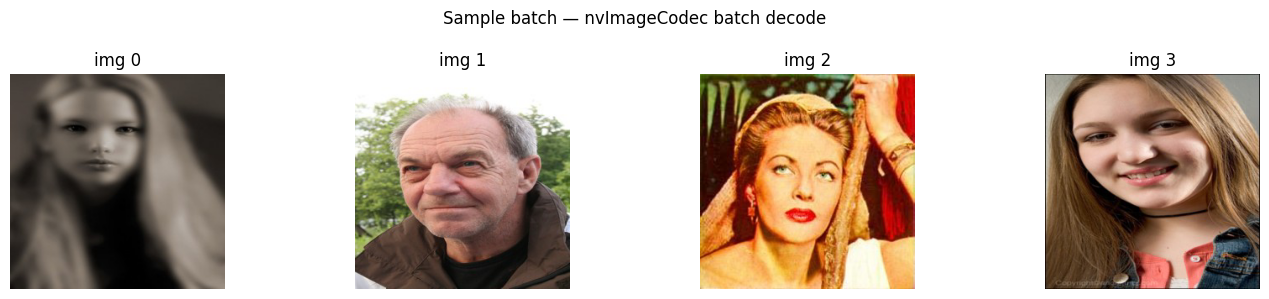

In [11]:
sample_batch, sample_labels = next(iter(nv_batch_loader))
print(f"Batch shape : {sample_batch.shape}   (N, C, H, W)")
print(f"Dtype       : {sample_batch.dtype}")
print(f"Device      : {sample_batch.device}")
print(f"Value range : [{sample_batch.min():.3f}, {sample_batch.max():.3f}]")

# Visualise first 4 images from the batch
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    ax.imshow(sample_batch[i].cpu().permute(1, 2, 0).numpy())
    ax.axis("off")
    ax.set_title(f"img {i}")
plt.suptitle("Sample batch — nvImageCodec batch decode")
plt.tight_layout()
plt.show()

# Shut down the Approach 2 spawn workers now that we're done sampling from this loader.
# Drop the sample tensors first — they carry CUDA IPC handles to memory the
# workers produced, and must be released before we join the worker processes.
del sample_batch, sample_labels
release_loader(nv_batch_loader)
del nv_batch_loader
gc.collect()
torch.cuda.empty_cache()

## Benchmark results

In [12]:
# ── Print table ─────────────────────────────────────────────────────────────
print(f"{'Approach':<50} {'img/s':>8} {'ms/batch':>10} {'Speedup':>9}")
print("-" * 80)

baseline_ips = results.get("PIL + torchvision", {}).get("images_per_sec", 1.0)

# Define display order
_order = [
    "PIL + torchvision",
    "nvImageCodec single (num_workers=0)",
    f"nvImageCodec single (num_workers={NUM_WORKERS})",
    f"nvImageCodec single + forkserver (num_workers={NUM_WORKERS})",
    "nvImageCodec batch decode",
]

for name in _order:
    if name not in results:
        continue
    r = results[name]
    speedup = r["images_per_sec"] / baseline_ips
    print(f"{name:<50} {r['images_per_sec']:>8.0f} {r['ms_per_batch']:>10.1f} {speedup:>8.2f}×")

Approach                                              img/s   ms/batch   Speedup
--------------------------------------------------------------------------------
PIL + torchvision                                      2395       13.3     1.00×
nvImageCodec single (num_workers=0)                     797       39.9     0.33×
nvImageCodec single (num_workers=8)                    4385        7.2     1.83×
nvImageCodec single + forkserver (num_workers=8)       4514        7.0     1.89×
nvImageCodec batch decode                              6358        5.0     2.65×


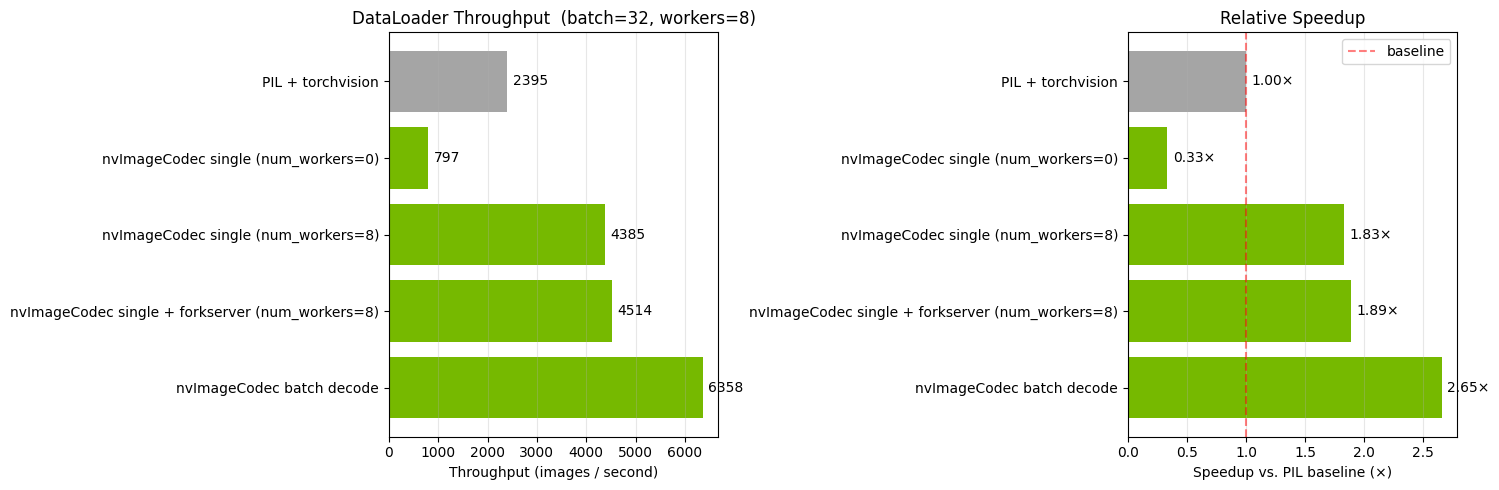

In [13]:
# ── Bar chart ────────────────────────────────────────────────────────────────
plot_names = [n for n in _order if n in results]
plot_ips   = [results[n]["images_per_sec"] for n in plot_names]
plot_speedups = [ips / baseline_ips for ips in plot_ips]

# Color: grey for baseline / PIL approaches, green for nvImageCodec approaches
colors = ["#76B900" if "nvImageCodec" in n else "#a5a5a5" for n in plot_names]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Throughput
bars = ax1.barh(plot_names, plot_ips, color=colors)
ax1.set_xlabel("Throughput (images / second)")
ax1.set_title(f"DataLoader Throughput  (batch={BATCH_SIZE}, workers={NUM_WORKERS})")
ax1.bar_label(bars, labels=[f"{v:.0f}" for v in plot_ips], padding=4)
ax1.invert_yaxis()
ax1.grid(axis="x", alpha=0.3)

# Speedup
bars2 = ax2.barh(plot_names, plot_speedups, color=colors)
ax2.set_xlabel("Speedup vs. PIL baseline (×)")
ax2.set_title("Relative Speedup")
ax2.axvline(1.0, color="red", linestyle="--", alpha=0.5, label="baseline")
ax2.bar_label(bars2, labels=[f"{v:.2f}×" for v in plot_speedups], padding=4)
ax2.invert_yaxis()
ax2.legend()
ax2.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
